In [ ]:
!pip install transformers datasets torch scikit-learn -q

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# Load dataset
dataset = load_dataset("emotion")

# Load model + tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=6
)

# Tokenize
def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Training args (SAFE VERSION)
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    logging_steps=50
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"]
)

# Train
trainer.train()

# Test
text = "I am very happy today"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
outputs = model(**inputs)

predicted_class = torch.argmax(outputs.logits).item()
print("Predicted class:", predicted_class)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

text = "I am very happy today"

inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
inputs = {key: val.to(device) for key, val in inputs.items()}

outputs = model(**inputs)

labels = ["sadness", "joy", "love", "anger", "fear", "surprise"]

predicted_class = torch.argmax(outputs.logits).item()
print("Emotion:", labels[predicted_class])

Emotion: joy


In [ ]:
texts = [
    "I am feeling very sad today",
    "I love this so much",
    "I am really scared right now",
    "This makes me so angry",
    "Wow I didn't expect this!",
    "I feel amazing and happy",
    "My life was terrible"
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

labels = ["sadness", "joy", "love", "anger", "fear", "surprise"]

for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {key: val.to(device) for key, val in inputs.items()}

    outputs = model(**inputs)
    predicted_class = torch.argmax(outputs.logits).item()

    print(f"Text: {text}")
    print(f"Emotion: {labels[predicted_class]}")
    print("-" * 50)

Text: I am feeling very sad today
Emotion: sadness
--------------------------------------------------
Text: I love this so much
Emotion: love
--------------------------------------------------
Text: I am really scared right now
Emotion: fear
--------------------------------------------------
Text: This makes me so angry
Emotion: anger
--------------------------------------------------
Text: Wow I didn't expect this!
Emotion: joy
--------------------------------------------------
Text: I feel amazing and happy
Emotion: joy
--------------------------------------------------
Text: My life was terrible
Emotion: sadness
--------------------------------------------------


In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.16148731112480164, 'eval_runtime': 63.6335, 'eval_samples_per_second': 31.43, 'eval_steps_per_second': 3.929, 'epoch': 2.0}


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
trainer = Trainer(
    model=model,  # your already trained model
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    compute_metrics=compute_metrics
)

In [ ]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.16148731112480164, 'eval_runtime': 64.9227, 'eval_samples_per_second': 30.806, 'eval_steps_per_second': 3.851, 'epoch': 2.0}


In [ ]:
preds = trainer.predict(dataset["validation"])

In [ ]:
import numpy as np

y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.933


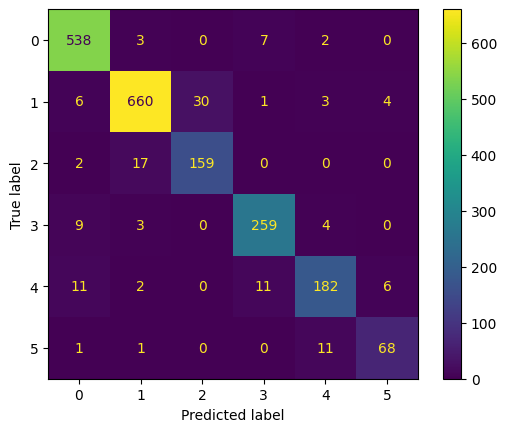

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [ ]:
from datasets import load_dataset

imdb = load_dataset("imdb")

In [ ]:
texts = [
    "This movie was absolutely fantastic!",
    "Worst movie I have ever seen",
    "It was okay, not great",
    "I loved the acting but the story was boring"
]

labels = ["sadness", "joy", "love", "anger", "fear", "surprise"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits).item()

    print(f"Review: {text}")
    print(f"Emotion: {labels[pred]}")
    print("-"*50)

Review: This movie was absolutely fantastic!
Emotion: joy
--------------------------------------------------
Review: Worst movie I have ever seen
Emotion: sadness
--------------------------------------------------
Review: It was okay, not great
Emotion: joy
--------------------------------------------------
Review: I loved the acting but the story was boring
Emotion: sadness
--------------------------------------------------


In [ ]:
def get_sentiment(text):
    if "worst" in text.lower() or "bad" in text.lower():
        return "Negative"
    else:
        return "Positive"

In [ ]:
for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)
    emotion = labels[torch.argmax(outputs.logits).item()]

    sentiment = get_sentiment(text)

    print(f"Review: {text}")
    print(f"Sentiment: {sentiment}")
    print(f"Emotion: {emotion}")
    print("-"*50)

Review: This movie was absolutely fantastic!
Sentiment: Positive
Emotion: joy
--------------------------------------------------
Review: Worst movie I have ever seen
Sentiment: Negative
Emotion: sadness
--------------------------------------------------
Review: It was okay, not great
Sentiment: Positive
Emotion: joy
--------------------------------------------------
Review: I loved the acting but the story was boring
Sentiment: Positive
Emotion: sadness
--------------------------------------------------


In [ ]:
model.save_pretrained("my_emotion_model")
tokenizer.save_pretrained("my_emotion_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('my_emotion_model/tokenizer_config.json', 'my_emotion_model/tokenizer.json')

In [ ]:
!zip -r my_emotion_model.zip my_emotion_model

  adding: my_emotion_model/ (stored 0%)
  adding: my_emotion_model/model.safetensors (deflated 7%)
  adding: my_emotion_model/tokenizer_config.json (deflated 42%)
  adding: my_emotion_model/config.json (deflated 56%)
  adding: my_emotion_model/tokenizer.json (deflated 71%)
